# Hotel Booking Demand - Exploratory Data Analysis

## Dataset Description

This dataset contains booking information for two types of hotels:
- City Hotel
- Resort Hotel

It includes booking dates, customer demographics, reservation details, cancellations, special requests, and other attributes.

Number of Rows: ~119,000
Number of Columns: 32

Target Variable:
- is_canceled (0 = Not Canceled, 1 = Canceled)

# Column Description

| Column | Description |
|---------|-------------|
| **hotel** | Type of hotel (`City Hotel` or `Resort Hotel`). |
| **is_canceled** | Whether the booking was canceled (1 = Yes, 0 = No). This is the target variable in many ML projects. |
| **lead_time** | Number of days between the booking date and the arrival date. |
| **arrival_date_year** | Year of arrival. |
| **arrival_date_month** | Month of arrival. |
| **arrival_date_week_number** | Week number of the year when the guest arrives. |
| **arrival_date_day_of_month** | Day of the month when the guest arrives. |
| **stays_in_weekend_nights** | Number of weekend nights (Saturday or Sunday) booked. |
| **stays_in_week_nights** | Number of weekday nights (Monday to Friday) booked. |
| **adults** | Number of adults included in the booking. |
| **children** | Number of children included in the booking. May contain missing values. |
| **babies** | Number of babies included in the booking. |
| **meal** | Type of meal booked (e.g., BB = Bed & Breakfast, HB = Half Board, FB = Full Board, SC = Self Catering). |
| **country** | Country of origin of the customer (ISO country code). |
| **market_segment** | Market segment through which the booking was made (e.g., Online TA, Direct, Corporate). |
| **distribution_channel** | Booking distribution channel (e.g., Direct, Travel Agent, GDS). |
| **is_repeated_guest** | Whether the customer has stayed at the hotel before (1 = Yes, 0 = No). |
| **previous_cancellations** | Number of previous bookings canceled by the customer before this booking. |
| **previous_bookings_not_canceled** | Number of previous bookings completed without cancellation. |
| **reserved_room_type** | Room type originally reserved by the customer. |
| **assigned_room_type** | Room type actually assigned at check-in. |
| **booking_changes** | Number of changes made to the booking before arrival. |
| **deposit_type** | Type of deposit made (`No Deposit`, `Refundable`, `Non Refund`). |
| **agent** | ID of the travel agent who made the booking. May contain missing values. |
| **company** | ID of the company responsible for the booking or payment. May contain many missing values. |
| **days_in_waiting_list** | Number of days the booking was on the waiting list before confirmation. |
| **customer_type** | Type of customer (e.g., Transient, Contract, Group, Transient-Party). |
| **adr** | Average Daily Rate (average room rental price per night). |
| **required_car_parking_spaces** | Number of parking spaces requested by the customer. |
| **total_of_special_requests** | Number of special requests made by the customer (e.g., high floor, twin bed). |
| **reservation_status** | Final reservation status (`Check-Out`, `Canceled`, `No-Show`). |
| **reservation_status_date** | Date when the reservation status was last updated. |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# DATA Ingestion and Cleaning


In [2]:
df= pd.read_csv('hotel_bookings.csv')

In [3]:
pd.set_option('display.max_columns', None)

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
df.shape

(119390, 32)

In [6]:
df.duplicated().sum()

31994

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.shape

(87396, 32)

In [9]:
df.isnull().sum()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             452
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             12193
company                           82137


In [10]:
df=df.drop(columns=['company'])

In [11]:
df['country'].nunique()

177

In [12]:

df['country'] = df['country'].fillna('Unknown')
df['children'] = df['children'].fillna(0)
df['agent'] = df['agent'].fillna(0)


df = df[(df['adults'] + df['children'] + df['babies']) > 0]
df = df[(df['adr'] >= 0) & (df['adr'] < 5000)]

In [13]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87228.000000,87228.000000,87228.000000,87228.000000,87228.000000,87228.000000,87228.000000,87228.000000,87228.00000,87228.000000,87228.000000,87228.000000,87228.000000,87228.000000,87228.000000,87228.000000,87228.000000,87228.000000,87228.000000
mean,0.275233,79.970216,2016.210345,26.835443,15.815850,1.004586,2.623905,1.879362,0.13890,0.010845,0.038554,0.030403,0.184035,0.268469,81.087850,0.746309,106.458639,0.084308,0.698950
std,0.446634,86.058654,0.686066,13.669173,8.835516,1.027365,2.039814,0.621731,0.45627,0.113705,0.192531,0.369349,1.733042,0.710612,109.976348,10.001115,51.881832,0.281662,0.832054
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,72.250000,0.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,98.200000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,0.000000,134.100000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.00000,10.000000,1.000000,26.000000,72.000000,18.000000,535.000000,391.000000,510.000000,8.000000,5.000000


In [14]:
df.describe(include='object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,87228,87228,87228,87228,87228,87228,87228,87228,87228,87228,87228,87228
unique,2,12,5,178,8,5,9,11,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2016-02-14
freq,53273,11242,67905,27354,51553,69027,56434,46282,86084,71861,63220,211


In [15]:
df.isnull().sum()
#duplicate rows removed and null values filled

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

# EDA

In [16]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

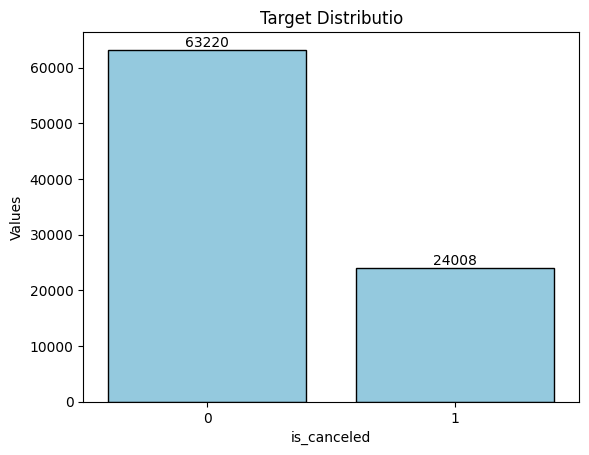

In [17]:
ax = sns.countplot(
    data=df,
    x='is_canceled',
    color='skyblue',
    edgecolor='black'
)

ax.bar_label(ax.containers[0])
plt.xlabel('is_canceled')
plt.ylabel('Values')
plt.title("Target Distributio")
plt.show()

In [18]:
df["is_canceled"].value_counts(normalize=True)*100

is_canceled
0    72.476728
1    27.523272
Name: proportion, dtype: float64

- 27.4 percent of bookings are cancelled

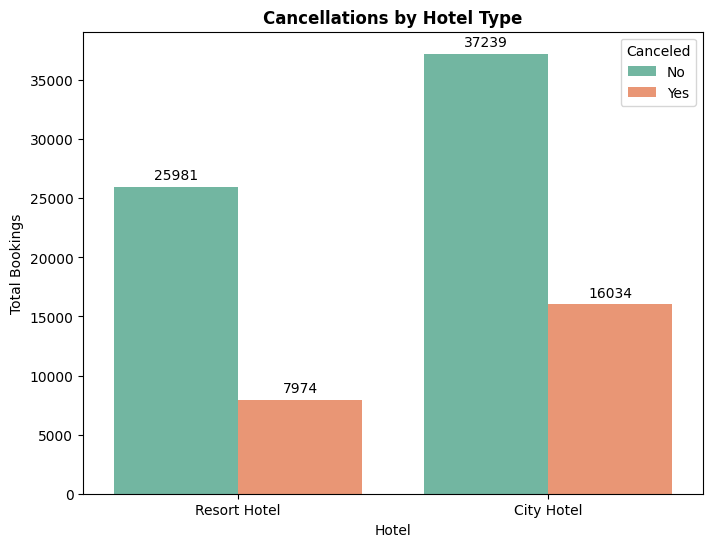

In [19]:
#cancellation by hotel type
plt.figure(figsize=(8, 6))
ax=sns.countplot( data=df, x='hotel', hue='is_canceled', palette='Set2')
for container in ax.containers:
  ax.bar_label(container, fmt='%d', padding=3, fontsize=10)
plt.title('Cancellations by Hotel Type', fontweight='bold')
plt.xlabel('Hotel')
plt.ylabel('Total Bookings')
plt.legend(title='Canceled', labels=['No', 'Yes'])

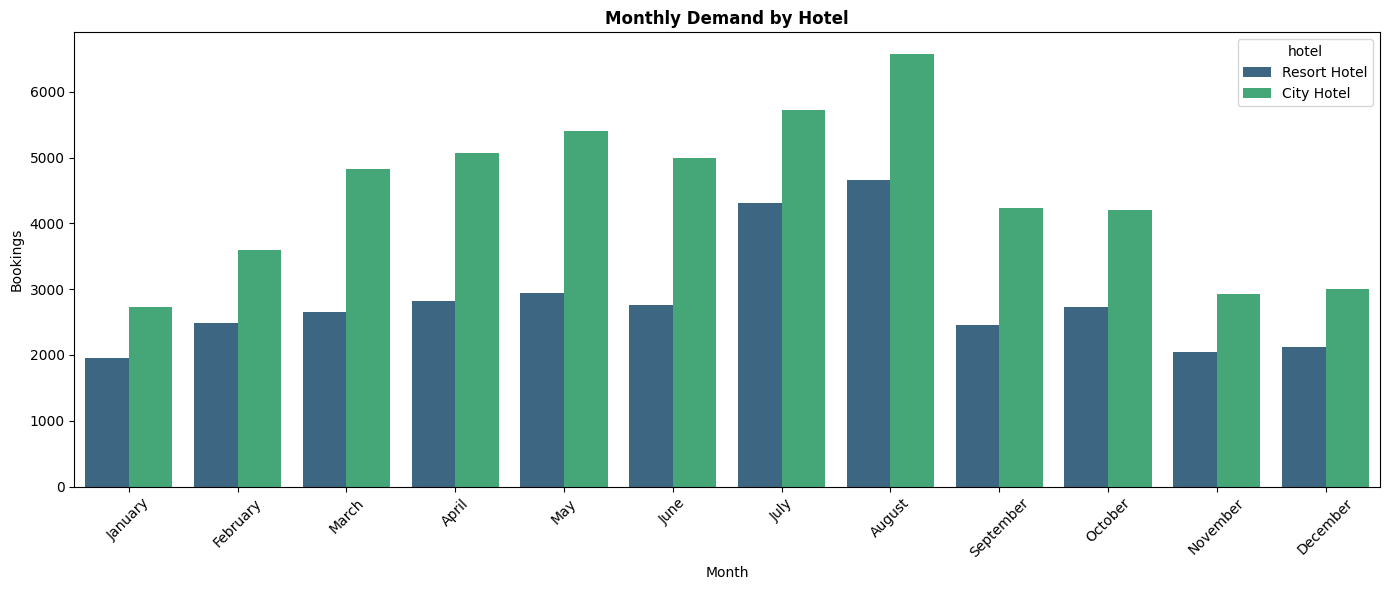

In [20]:
#monthly demand trends
plt.figure(figsize=(14, 6))
month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December',
]
sns.countplot(
    data=df,
    x='arrival_date_month',
    order=month_order,
    hue='hotel',
    palette='viridis',
)
plt.title('Monthly Demand by Hotel', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Bookings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\NishantHP\AppData\Local\Temp\ipykernel_15528\2199546601.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


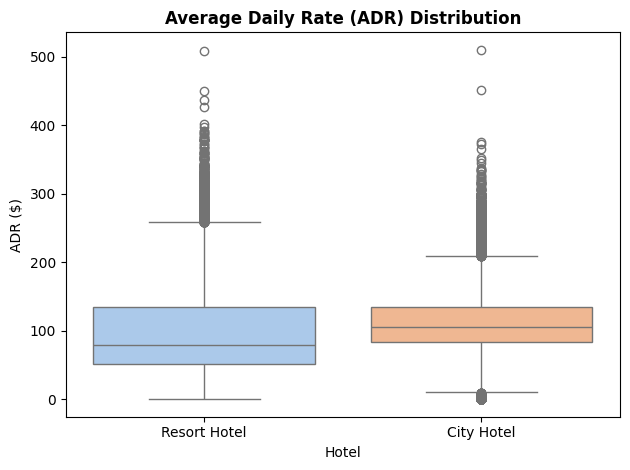

In [21]:
# ADR (Average Daily Rate) Distribution (filtering extreme outlier)
sns.boxplot(
    
    data=df[df['adr'] < 1000],
    x='hotel',
    y='adr',
    palette='pastel',
)
plt.title(
    'Average Daily Rate (ADR) Distribution', fontweight='bold')
plt.xlabel('Hotel')
plt.ylabel('ADR ($)')
plt.tight_layout()
plt.show()

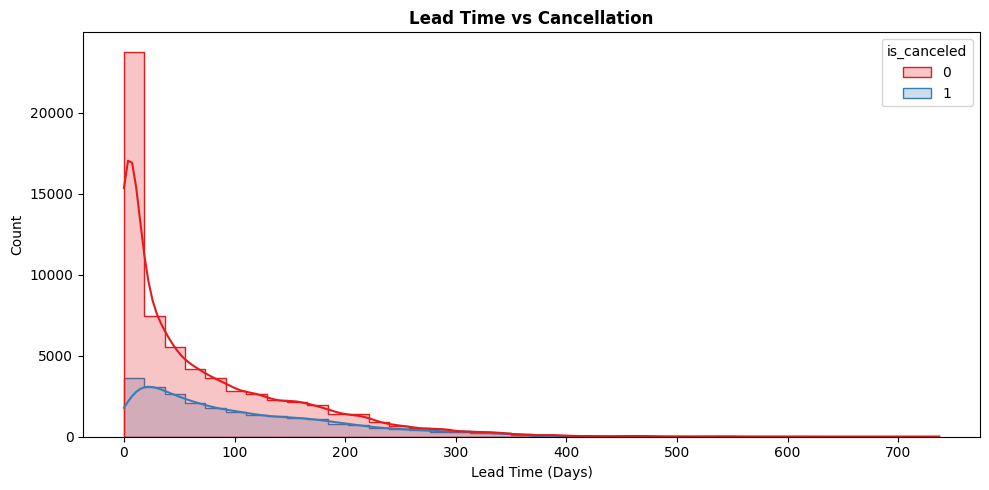

In [22]:
# Lead Time Impact on Cancellations
plt.figure(figsize=(10,5))
sns.histplot(    
    data=df,
    x='lead_time',
    hue='is_canceled',
    kde=True,
    element='step',
    bins=40,
    palette='Set1',
)
plt.title('Lead Time vs Cancellation', fontweight='bold')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Key Takeaways

* **Cancellations by Hotel Type:** City Hotels handle higher booking volumes but face significantly higher cancellation rates than Resort Hotels.
* **Monthly Demand Trends:** Bookings follow a strong summer peak (July–August) and drop to their lowest in winter (November–January).
* **ADR Distribution:** City Hotels command a slightly higher median daily rate, while Resort Hotels display wider seasonal price variance.
* **Lead Time vs. Cancellation:** Shorter lead times (<30 days) yield reliable check-ins, whereas bookings made far in advance (>150 days) carry high cancellation risk.

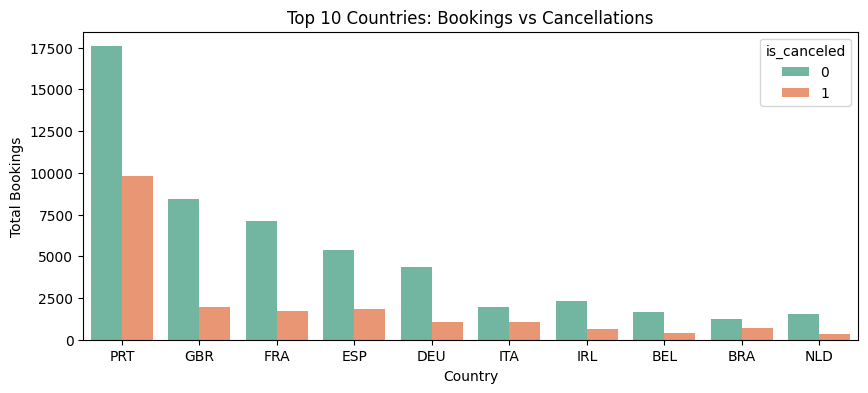

In [23]:
#top countries on the booking and cancellation
top_10_countries = df['country'].value_counts().head(10).index
plt.figure(figsize=(10, 4))
sns.countplot(
    data=df[df['country'].isin(top_10_countries)],
    x='country',
    order=top_10_countries,
    hue='is_canceled',
    palette='Set2',
)
plt.title('Top 10 Countries: Bookings vs Cancellations')
plt.xlabel('Country')
plt.ylabel('Total Bookings')
plt.show()

C:\Users\NishantHP\AppData\Local\Temp\ipykernel_15528\41363379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


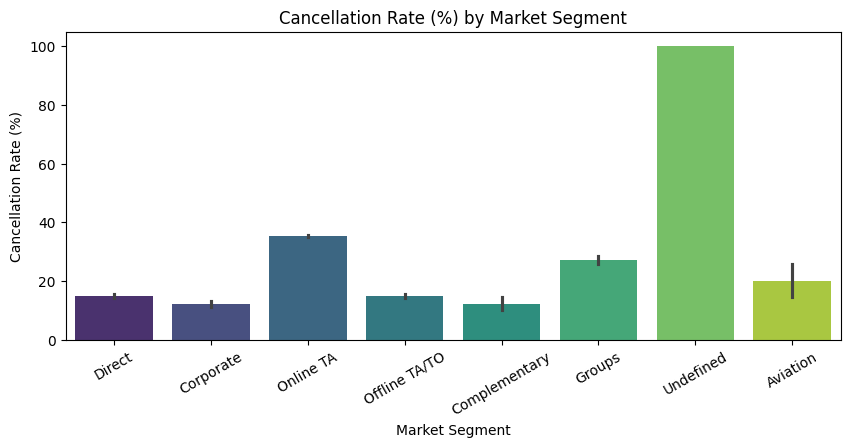

In [24]:
#Cancellation Rate (%) by Market Segment
plt.figure(figsize=(10, 4))
sns.barplot(
    data=df,
    x='market_segment',
    y='is_canceled',
    estimator=lambda x: np.mean(x) * 100,
    palette='viridis',
)
plt.title('Cancellation Rate (%) by Market Segment')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Market Segment')
plt.xticks(rotation=30)
plt.show()

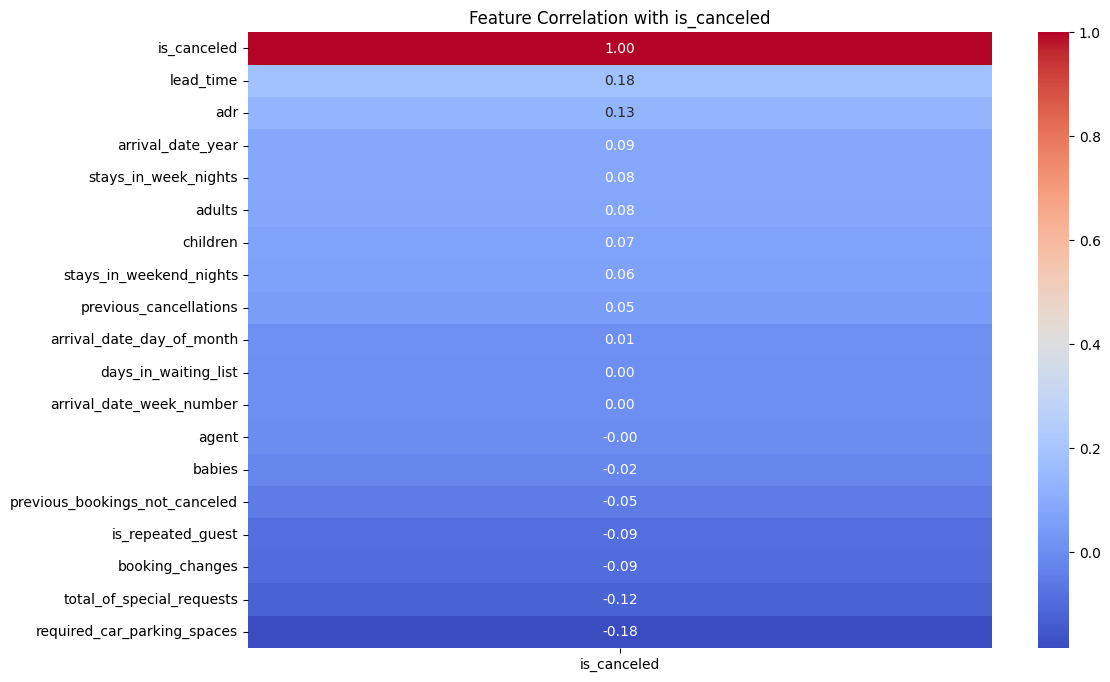

In [25]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(
    corr[['is_canceled']].sort_values(by='is_canceled', ascending=False),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
)
plt.title('Feature Correlation with is_canceled')
plt.show()

# ML part 

In [26]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [27]:
#dropping columns 
ls_drop = [
    'reservation_status',
    'reservation_status_date',
    'arrival_date_year',
    'arrival_date_week_number',
    'agent'
]
df_ml = df.drop(columns=ls_drop)

In [28]:
# Feature Engineering
df_ml['total_stay'] = (
    df_ml['stays_in_weekend_nights'] + df_ml['stays_in_week_nights']
)

In [29]:
df_ml['total_guests'] = (
    df_ml['adults'] + df_ml['children'].fillna(0) + df_ml['babies']
)

In [30]:
df_ml['room_mismatch'] = (
    df_ml['reserved_room_type'] != df_ml['assigned_room_type']
).astype(int)

In [31]:
top_countries = ['PRT', 'GBR', 'FRA', 'ESP', 'DEU', 'ITA', 'IRL']
df_ml['country'] = df_ml['country'].apply(
    lambda x: x if x in top_countries else 'Other'
)

In [32]:
#spliting data
X = df_ml.drop(columns=['is_canceled'])
y = df_ml['is_canceled']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [44]:
model={'DecisionTreeClassifier':DecisionTreeClassifier(
            max_depth=8,
            min_samples_split=20,
            min_samples_leaf=10,
            class_weight='balanced',
            random_state=42
        ),
        'XGBClassifier':XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss',
            random_state=42
        ),
        'LogisticRegression':LogisticRegression(
            max_iter=1000, 
            random_state=42, 
            class_weight='balanced'),
        'RandomForestClassifier':RandomForestClassifier(
            n_estimators=200, 
            max_depth=12, 
            random_state=42, 
            class_weight='balanced'),
      }

In [34]:
# creating pipelines
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

preprocessor=ColumnTransformer([
    ('num',StandardScaler(),num_cols),
    ('cat',OneHotEncoder(handle_unknown='ignore', sparse_output=False),cat_cols)])

In [35]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

In [45]:
scores={}

for i in range(len(list(model))):
    mdl=list(model.values())[i]
    mdl.fit(X_train_processed,y_train)
    y_predict=mdl.predict(X_test_processed)
    score=accuracy_score(y_test,y_predict)
    scores[list(model.keys())[i]]=score
    print(f'The the classification report of {list(model.keys())[i]}:')
    print(classification_report(y_test,y_predict))


The the classification report of DecisionTreeClassifier:
              precision    recall  f1-score   support

           0       0.94      0.66      0.78     12644
           1       0.50      0.89      0.64      4802

    accuracy                           0.72     17446
   macro avg       0.72      0.77      0.71     17446
weighted avg       0.82      0.72      0.74     17446

The the classification report of XGBClassifier:
              precision    recall  f1-score   support

           0       0.87      0.91      0.89     12644
           1       0.74      0.64      0.68      4802

    accuracy                           0.84     17446
   macro avg       0.80      0.78      0.79     17446
weighted avg       0.83      0.84      0.83     17446

The the classification report of LogisticRegression:
              precision    recall  f1-score   support

           0       0.91      0.72      0.81     12644
           1       0.53      0.81      0.64      4802

    accuracy            

## Final Model Evaluation & Conclusion

### 1. Performance Summary

| Model | Accuracy | Class 1 Precision *(Canceled)* | Class 1 Recall *(Canceled)* | Class 1 F1-Score | Macro Avg F1 | Weighted Avg F1 |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **XGBClassifier** | **0.84** | **0.74** | 0.64 | **0.68** | **0.79** | **0.83** |
| **RandomForestClassifier** | 0.75 | 0.53 | 0.88 | 0.66 | 0.73 | 0.76 |
| **LogisticRegression** | 0.75 | 0.53 | 0.81 | 0.64 | 0.72 | 0.76 |
| **DecisionTreeClassifier** | 0.72 | 0.50 | **0.89** | 0.64 | 0.71 | 0.74 |

---